```{"id":"47633","variant":"standard","title":"Description of Bayesian Coordination Simulation Model"}
This simulation models a small coordination game in which agents with different belief profiles repeatedly choose between two competing projects. Each project has an objective probability of success, but this is unknown to the agents. Instead, each agent holds subjective beliefs about each project’s likelihood of success, which evolve through Bayesian-style updating based on observed outcomes. The system thus captures how social learning and probabilistic reasoning influence coordination over time.

At the start, two agents act as “leaders” with strong, asymmetric priors—each strongly favoring a different project—while the three “followers” begin with flat, uninformed priors. In each round, every agent independently chooses a project to support by sampling from their belief distribution: the higher an agent’s belief in a project’s success, the more likely they are to choose it. Projects only execute if at least two agents choose them, introducing a coordination dependency between decisions.

Once projects are selected, their outcomes are determined by true success probabilities: one project is inherently more promising (70% success) and the other less so (40%). When a project succeeds, all agents who chose it receive payments proportional to the strength of their belief in that project, rewarding confidence that aligns with success. If the project fails or fails to execute, no payments are made. This mechanism encourages agents to both coordinate and calibrate their confidence to empirical outcomes.

After each round, agents update their beliefs using a bounded Bayesian learning rule. Success strengthens belief in the chosen project, while failure weakens it, with updates moderated by a learning rate and beliefs renormalized to sum to one. Over successive rounds, these updates drive belief convergence or persistent polarization, depending on feedback from collective outcomes and stochastic coordination patterns.

The simulation’s output includes round-by-round records of beliefs, project choices, successes, and payments. Visualizations show how individual beliefs evolve over time, revealing how collective experience shapes perception of which project is better. The model can be interpreted as a simple adaptive system combining social coordination, probabilistic learning, and incentive alignment—a microcosm of organizational decision-making under uncertainty.
```


In [1]:
# Install JAX (Colab usually has it, but this ensures you have it)
!pip install jax jaxlib

# Install memo
!pip install memo-lang




[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip



--- Round 1 ---
  Project 1: 2 workers
  Project 2: 3 workers
  Project 1: Success ✓
    Payments: Leader A: $61.54, Follower 1: $38.46
  Project 2: Failed ✗

--- Round 2 ---
  Project 1: 3 workers
  Project 2: 2 workers
  Project 1: Success ✓
    Payments: Leader A: $41.29, Follower 1: $28.77, Follower 3: $29.94
  Project 2: Failed ✗

--- Round 3 ---
  Project 1: 3 workers
  Project 2: 2 workers
  Project 1: Success ✓
    Payments: Leader A: $38.97, Follower 1: $29.19, Follower 2: $31.84
  Project 2: Failed ✗

--- Round 4 ---
  Project 1: 4 workers
  Project 2: 1 workers
  Project 1: Success ✓
    Payments: Leader A: $28.66, Follower 1: $22.61, Follower 2: $24.18, Follower 3: $24.56
  Project 2: Not executed -

--- Round 5 ---
  Project 1: 4 workers
  Project 2: 1 workers
  Project 1: Success ✓
    Payments: Leader A: $28.09, Follower 1: $23.02, Follower 2: $24.29, Follower 3: $24.60
  Project 2: Not executed -

=== Final Beliefs ===
Leader A: Project 1 = 84.6%, Project 2 = 15.4%
Lea

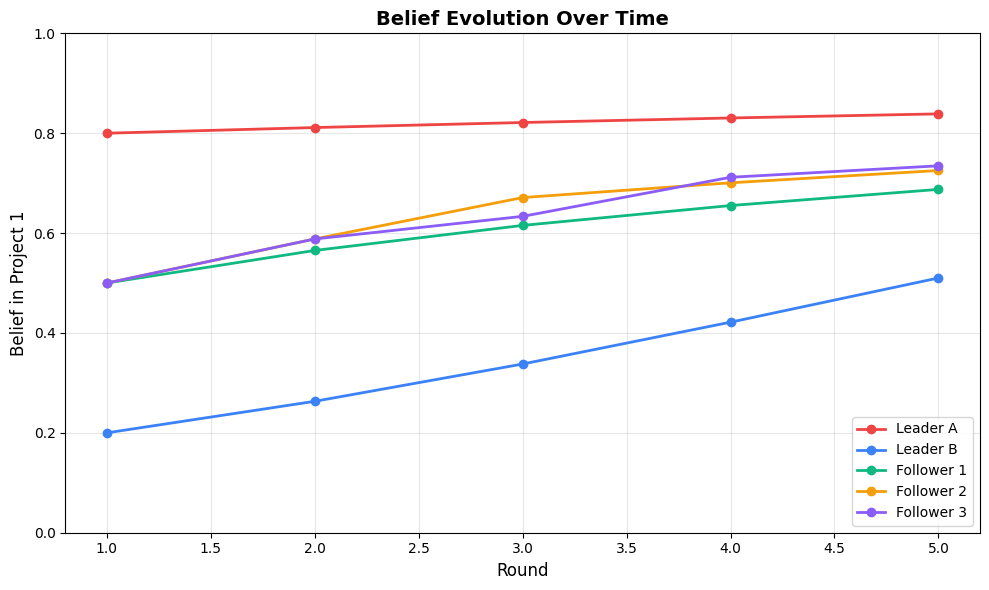

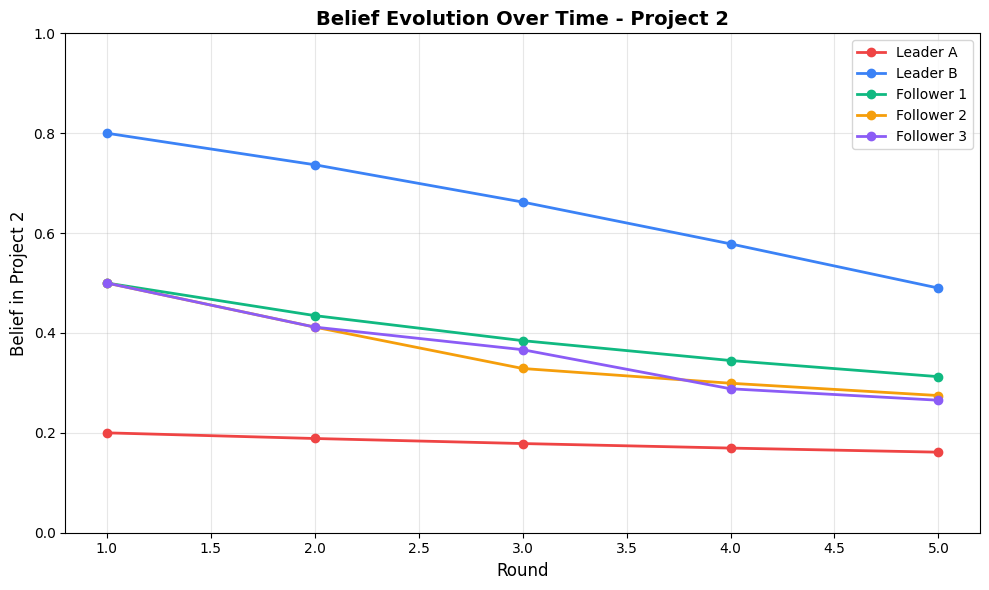

In [2]:


import jax.numpy as jnp
import random
import matplotlib.pyplot as plt

# Define agent and project types as lists
agent_names = ['Leader A', 'Leader B', 'Follower 1', 'Follower 2', 'Follower 3']
projects = ['Project 1', 'Project 2']

# True success probabilities (fixed)
true_success_prob = {'Project 1': 0.7, 'Project 2': 0.4}

# Initialize beliefs: leaders have strong priors, followers have flat priors
initial_beliefs = {
    'Leader A': {'Project 1': 0.8, 'Project 2': 0.2},
    'Leader B': {'Project 1': 0.2, 'Project 2': 0.8},
    'Follower 1': {'Project 1': 0.5, 'Project 2': 0.5},
    'Follower 2': {'Project 1': 0.5, 'Project 2': 0.5},
    'Follower 3': {'Project 1': 0.5, 'Project 2': 0.5}
}

def agent_chooses_project(agent, beliefs):
    """Agent chooses a project based on their current beliefs"""
    # Agent samples from their belief distribution
    rand = random.random()
    if rand < beliefs[agent]['Project 1']:
        return 'Project 1'
    else:
        return 'Project 2'

def calculate_payments(choices, beliefs, successes):
    """Calculate payments for agents based on belief strength"""
    payments = {agent: 0.0 for agent in agent_names}

    for project in projects:
        if not successes[project]:
            continue  # No payment if project failed or didn't execute

        # Find workers and their belief strengths
        workers = []
        total_belief = 0.0
        for agent in agent_names:
            if choices[agent] == project:  # Agent chose this project
                belief_strength = beliefs[agent][project]
                workers.append((agent, belief_strength))
                total_belief += belief_strength

        if total_belief > 0:  # Avoid division by zero
            # Distribute $100 proportional to belief strength
            total_pot = 100.0
            for agent, belief_strength in workers:
                payments[agent] = (belief_strength / total_belief) * total_pot

    return payments

def bayesian_update(beliefs, agent, chosen_project, success, learning_rate=0.3):
    """Update agent's beliefs based on project outcome"""
    new_beliefs = beliefs[agent].copy()

    if success:
        # Success: increase belief in chosen project
        new_beliefs[chosen_project] = min(0.95,
            beliefs[agent][chosen_project] + learning_rate * (1 - beliefs[agent][chosen_project]))
    else:
        # Failure: decrease belief in chosen project
        new_beliefs[chosen_project] = max(0.05,
            beliefs[agent][chosen_project] - learning_rate * beliefs[agent][chosen_project])

    # Normalize so beliefs sum to 1
    total = sum(new_beliefs.values())
    for p in projects:
        new_beliefs[p] = new_beliefs[p] / total

    return new_beliefs

def run_simulation(num_rounds=5):
    """Run the full simulation for multiple rounds"""
    beliefs = {agent: initial_beliefs[agent].copy() for agent in agent_names}
    history = []

    for round_num in range(num_rounds):
        print(f"\n--- Round {round_num + 1} ---")

        # Step 1: Agents choose projects based on beliefs
        choices = {}
        for agent in agent_names:
            choices[agent] = agent_chooses_project(agent, beliefs)

        # Step 2: Check which projects execute (>=2 workers)
        executes = {}
        for project in projects:
            worker_count = sum([1 for agent in agent_names if choices[agent] == project])
            executes[project] = worker_count >= 2
            print(f"  {project}: {worker_count} workers")

        # Step 3: Determine project success
        successes = {}
        for project in projects:
            if executes[project]:
                successes[project] = random.random() < true_success_prob[project]
            else:
                successes[project] = False

        # Step 4: Calculate and distribute payments
        payments = calculate_payments(choices, beliefs, successes)

        # Step 5: Bayesian update of beliefs
        new_beliefs = {}
        for agent in agent_names:
            chosen_project = choices[agent]
            success = successes[chosen_project]
            new_beliefs[agent] = bayesian_update(beliefs, agent, chosen_project, success)

        # Save round history
        history.append({
            'round': round_num + 1,
            'beliefs': {agent: beliefs[agent].copy() for agent in agent_names},
            'choices': choices.copy(),
            'successes': successes.copy(),
            'payments': payments.copy()
        })

        # Print round results
        for project in projects:
            workers = [a for a in agent_names if choices[a] == project]
            status = 'Success ✓' if successes[project] else ('Failed ✗' if executes[project] else 'Not executed -')
            print(f"  {project}: {status}")
            if payments and any(payments[a] > 0 for a in workers):
                print(f"    Payments: {', '.join([f'{a}: ${payments[a]:.2f}' for a in workers if payments[a] > 0])}")

        beliefs = new_beliefs

    return history, beliefs

# Run simulation
history, final_beliefs = run_simulation(num_rounds=5)

# Print final beliefs
print("\n=== Final Beliefs ===")
for agent in agent_names:
    print(f"{agent}: Project 1 = {final_beliefs[agent]['Project 1']:.1%}, Project 2 = {final_beliefs[agent]['Project 2']:.1%}")

# Print total earnings
print("\n=== Total Earnings ===")
total_earnings = {agent: sum([h['payments'][agent] for h in history]) for agent in agent_names}
for agent in agent_names:
    print(f"{agent}: ${total_earnings[agent]:.2f}")

# Plot belief evolution over time
rounds = [h['round'] for h in history]
belief_evolution = {agent: [h['beliefs'][agent]['Project 1'] for h in history]
                   for agent in agent_names}

plt.figure(figsize=(10, 6))
colors = ['#ef4444', '#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']
for i, agent in enumerate(agent_names):
    plt.plot(rounds, belief_evolution[agent], marker='o', label=agent, linewidth=2, color=colors[i])

plt.xlabel('Round', fontsize=12)
plt.ylabel('Belief in Project 1', fontsize=12)
plt.title('Belief Evolution Over Time', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot belief evolution for Project 2
plt.figure(figsize=(10, 6))
belief_evolution_p2 = {agent: [h['beliefs'][agent]['Project 2'] for h in history]
                       for agent in agent_names}

colors = ['#ef4444', '#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']
for i, agent in enumerate(agent_names):
    plt.plot(rounds, belief_evolution_p2[agent], marker='o', label=agent, linewidth=2, color=colors[i])

plt.xlabel('Round', fontsize=12)
plt.ylabel('Belief in Project 2', fontsize=12)
plt.title('Belief Evolution Over Time - Project 2', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()